#### TOPIC: EXAMINING FACTORS THAT AFFESTED JAMB PERFORMANCE IN 2024

### What to learn from this project:
#### . Data cleaning and processing
#### . data visualization
#### . Exploratory Data Analysis(EDA)
#### . Intermediate statistical analysis and interpretation
#### . critical thinking and problem solving
#### . drawing actionable insights from data

In [1]:
# importing all the necessary library

import pandas as pd
import matplotlib.pyplot as plt # libraries for visuals
import seaborn as sns # library for visuals
import matplotlib.ticker as mtick # used for customizing the plot to display exact figure
from matplotlib.ticker import ScalarFormatter # for proper scaling of the plot
from scipy.stats import pearsonr # used for statistical calculations
import numpy as np


# reading the csv data into pandas
df1 = pd.read_csv('academic_performance.csv')
df2 = pd.read_csv('students_info.csv')
df3 = pd.read_csv('school_factors.csv')
df4 = pd.read_csv('home_environment.csv')
df5 = pd.read_csv('attendance_resources.csv')



In [2]:
# checking the columns of all the individual data to get a common column which will be used to merge the data.

df1.columns

Index(['student_id', 'jamb_score', 'study_hours_per_week',
       'assignments_completed'],
      dtype='object')

In [3]:
df2.columns

Index(['student_id', 'age', 'gender', 'socioeconomic_status',
       'parent_education_level'],
      dtype='object')

In [4]:
df3.columns

Index(['student_id', 'teacher_quality', 'distance_to_school', 'school_type',
       'school_location'],
      dtype='object')

In [5]:
df4.columns

Index(['student_id', 'parent_involvement', 'it_knowledge'], dtype='object')

In [6]:
df5.columns

Index(['student_id', 'attendance_rate', 'extra_tutorials',
       'access_to_learning_materials'],
      dtype='object')

In [7]:
# the column uniform to all dataset is the student_id column

# merging all data with refernce to the uniform data,



df =df1.merge(df2, on='student_id').merge(df3, on='student_id').merge(df4, on= 'student_id').merge(df5, on='student_id')
df



,student_id,jamb_score,study_hours_per_week,assignments_completed,age,gender,socioeconomic_status,parent_education_level,teacher_quality,distance_to_school,school_type,school_location,parent_involvement,it_knowledge,attendance_rate,extra_tutorials,access_to_learning_materials
0,1,192,22.0,2,17,Male,Low,Tertiary,4.0,12.4,Public,Urban,High,Medium,78.0,Yes,Yes
1,2,207,14.0,1,15,Male,High,NaN,4.0,2.7,Public,Rural,High,High,88.0,No,Yes
2,3,182,29.0,2,20,Female,High,Tertiary,2.0,9.6,Public,Rural,High,Medium,87.0,Yes,Yes
3,4,210,29.0,1,22,Female,Medium,Tertiary,2.0,2.6,Public,Urban,Medium,High,99.0,No,Yes
4,5,199,12.0,1,22,Female,Medium,Tertiary,3.0,8.8,Public,Urban,Medium,Medium,98.0,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,183,20.0,2,16,Male,Medium,Primary,2.0,10.6,Public,Urban,Low,Low,74.0,Yes,No
4996,4997,179,0.0,1,22,Male,Low,Secondary,2.0,20.0,Public,Rural,Medium,Medium,80.0,No,Yes
4997,4998,261,17.0,3,18,Male,Medium,Primary,3.0,11.3,Public,Urban,Low,High,89.0,No,No
4998,4999,183,15.0,1,18,Male,Medium,Secondary,2.0,15.9,Public,Rural,Low,Medium,96.0,No,No


### EXPLORING THE DATA

In [8]:
df.describe()

,student_id,jamb_score,study_hours_per_week,assignments_completed,age,teacher_quality,distance_to_school,attendance_rate
count,5000.000000,5000.000000,4991.000000,5000.000000,5000.000000,4978.000000,4923.000000,4972.000000
mean,2500.500000,174.074600,19.523142,1.804600,18.445800,2.520892,10.009039,84.216412
std,1443.520003,47.616477,9.630936,0.992076,2.301504,0.985563,4.824701,9.497230
min,1.000000,100.000000,0.000000,1.000000,15.000000,1.000000,0.000000,50.000000
25%,1250.750000,135.000000,13.000000,1.000000,16.000000,2.000000,6.600000,78.000000
50%,2500.500000,170.000000,19.000000,1.000000,18.000000,2.000000,10.000000,84.000000
75%,3750.250000,209.000000,26.000000,2.000000,20.000000,3.000000,13.500000,91.000000
max,5000.000000,367.000000,40.000000,5.000000,22.000000,5.000000,20.000000,100.000000


In [9]:
df.shape

(5000, 17)

In [10]:
df.columns

Index(['student_id', 'jamb_score', 'study_hours_per_week',
       'assignments_completed', 'age', 'gender', 'socioeconomic_status',
       'parent_education_level', 'teacher_quality', 'distance_to_school',
       'school_type', 'school_location', 'parent_involvement', 'it_knowledge',
       'attendance_rate', 'extra_tutorials', 'access_to_learning_materials'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   student_id                    5000 non-null   int64  
 1   jamb_score                    5000 non-null   int64  
 2   study_hours_per_week          4991 non-null   float64
 3   assignments_completed         5000 non-null   int64  
 4   age                           5000 non-null   int64  
 5   gender                        5000 non-null   object 
 6   socioeconomic_status          5000 non-null   object 
 7   parent_education_level        4109 non-null   object 
 8   teacher_quality               4978 non-null   float64
 9   distance_to_school            4923 non-null   float64
 10  school_type                   4899 non-null   object 
 11  school_location               4935 non-null   object 
 12  parent_involvement            4983 non-null   object 
 13  it_

In [12]:
df.isnull().sum()

student_id                        0
jamb_score                        0
study_hours_per_week              9
assignments_completed             0
age                               0
gender                            0
socioeconomic_status              0
parent_education_level          891
teacher_quality                  22
distance_to_school               77
school_type                     101
school_location                  65
parent_involvement               17
it_knowledge                      5
attendance_rate                  28
extra_tutorials                  36
access_to_learning_materials     15
dtype: int64

#### fillilg the missing values.

##### firstly you need to check the values of those columns with missing values

In [13]:
# filling the missing values based on proportionality
# this code fills up all the missing values in every column with even proportion

def fill_missing_with_proportions(df):
    for column in df.columns:
        if df[column].isna().sum() > 0:
            value_counts = df[column].value_counts(normalize = True, dropna = True)
            choices = value_counts.index
            probabilities = value_counts.values
            num_missing = df[column].isna().sum()
            random_choices = np.random.choice(choices, size = num_missing, p=probabilities)
            df.loc[df[column].isna(), column] = random_choices
    return df

# calling the function
df = fill_missing_with_proportions(df)

In [14]:
value_counts = df['school_type'].value_counts(normalize = True, dropna = True)*100
value_counts

school_type
Public     74.6
Private    25.4
Name: proportion, dtype: float64

In [15]:
 df['school_type'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Public
1       Public
2       Public
3       Public
4       Public
         ...  
4995    Public
4996    Public
4997    Public
4998    Public
4999    Public
Name: school_type, Length: 5000, dtype: object>

In [16]:
df.isnull().sum()

student_id                      0
jamb_score                      0
study_hours_per_week            0
assignments_completed           0
age                             0
gender                          0
socioeconomic_status            0
parent_education_level          0
teacher_quality                 0
distance_to_school              0
school_type                     0
school_location                 0
parent_involvement              0
it_knowledge                    0
attendance_rate                 0
extra_tutorials                 0
access_to_learning_materials    0
dtype: int64

In [17]:
# frequency distribution for categorical variables
categorical_columns=['school_type', 'school_location', 'extra_tutorials', 'socioeconomic_status', 'parent_education_level', 'it_knowledge', 'gender']

for column in categorical_columns:
    print(f"Frequency distribution for {column}")
    print(df[column].value_counts())

Frequency distribution for school_type
school_type
Public     3730
Private    1270
Name: count, dtype: int64
Frequency distribution for school_location
school_location
Urban    2838
Rural    2162
Name: count, dtype: int64
Frequency distribution for extra_tutorials
extra_tutorials
Yes    2724
No     2276
Name: count, dtype: int64
Frequency distribution for socioeconomic_status
socioeconomic_status
Medium    1967
Low       1951
High      1082
Name: count, dtype: int64
Frequency distribution for parent_education_level
parent_education_level
Secondary    1905
Primary      1618
Tertiary     1477
Name: count, dtype: int64
Frequency distribution for it_knowledge
it_knowledge
Medium    1970
Low       1843
High      1187
Name: count, dtype: int64
Frequency distribution for gender
gender
Female    2530
Male      2470
Name: count, dtype: int64


C:\Users\Samuel C. Agbai\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


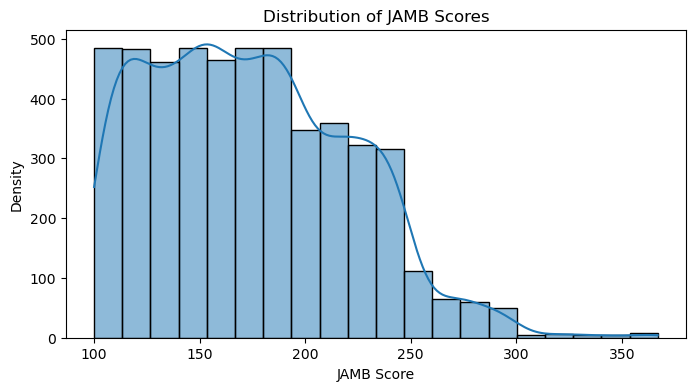

In [18]:
# Histogram for 'jamb_score'
plt.figure(figsize=(8, 4))
sns.histplot(df['jamb_score'], bins=20, kde=True)
plt.title("Distribution of JAMB Scores")
plt.xlabel("JAMB Score")
plt.ylabel("Density")
plt.show()

# Study_Hours_Per_Week
plt.figure(figsize=(8, 4))
sns.histplot(df['study_hours_per_week'], bins=15, kde=True)
plt.title("Distribution of Study Hours Per Week")
plt.show()

C:\Users\Samuel C. Agbai\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


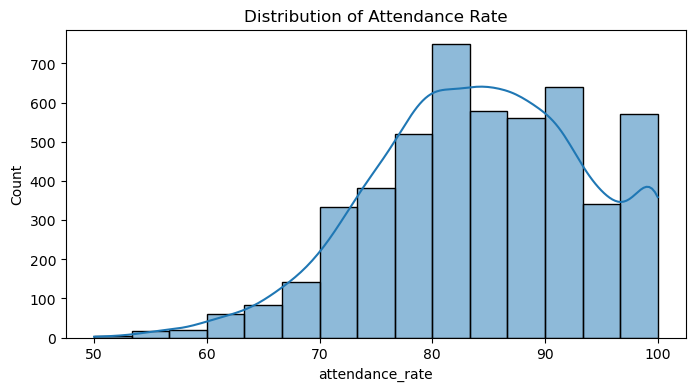

In [20]:
# Attendance_Rate
plt.figure(figsize=(8, 4))
sns.histplot(df['attendance_rate'], bins=15, kde=True)
plt.title("Distribution of Attendance Rate")
plt.show()

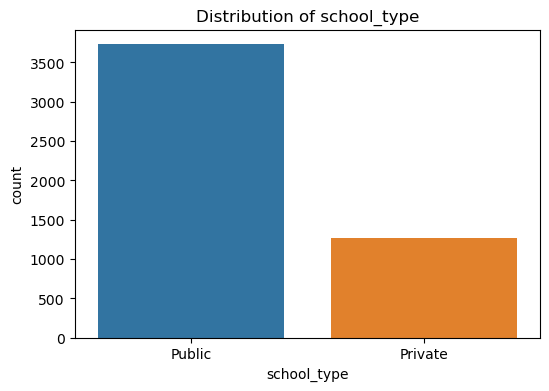

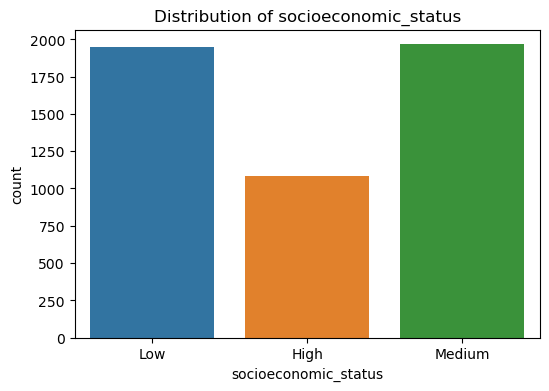

In [21]:
# Counts of School_Type, Socioeconomic_Status
for col in ['school_type', 'socioeconomic_status']:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

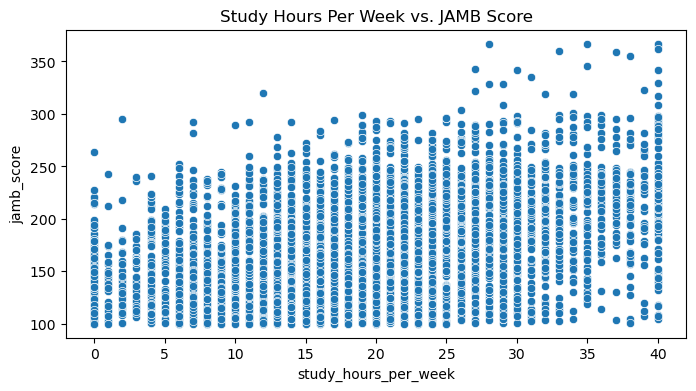

In [22]:
# Study_Hours_per_Week vs. JAMB_Score
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='study_hours_per_week', y='jamb_score')
plt.title("Study Hours Per Week vs. JAMB Score")
plt.show()

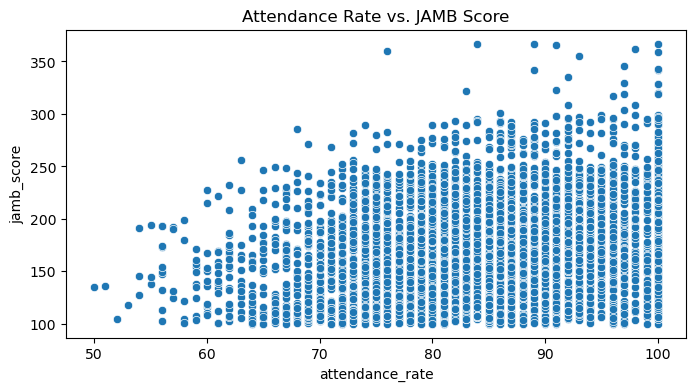

In [23]:
# Attendance_Rate vs. JAMB_Score
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='attendance_rate', y='jamb_score')
plt.title("Attendance Rate vs. JAMB Score")
plt.show()

Text(0.5, 1.0, 'Teacher Quality vs. JAMB Score')

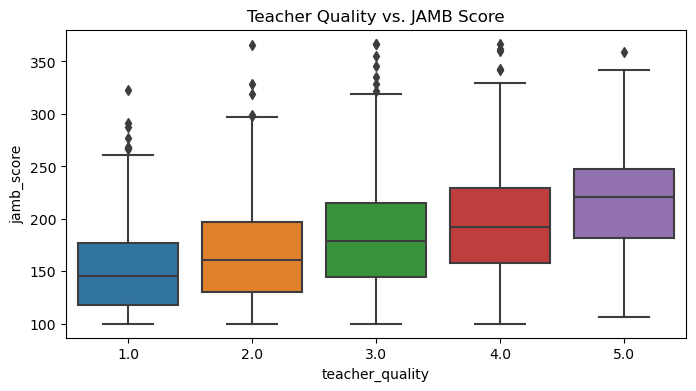

In [24]:
# Categorical variables - Teacher_Quality vs JAMB_Score
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='teacher_quality', y='jamb_score')
plt.title("Teacher Quality vs. JAMB Score")

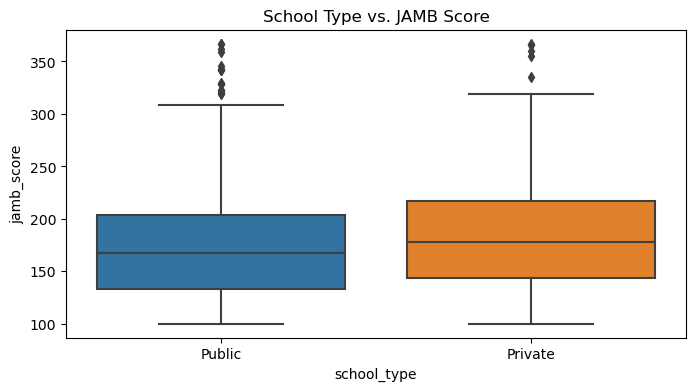

In [25]:
# School_Type vs. JAMB_Score
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='school_type', y='jamb_score')
plt.title("School Type vs. JAMB Score")
plt.show()

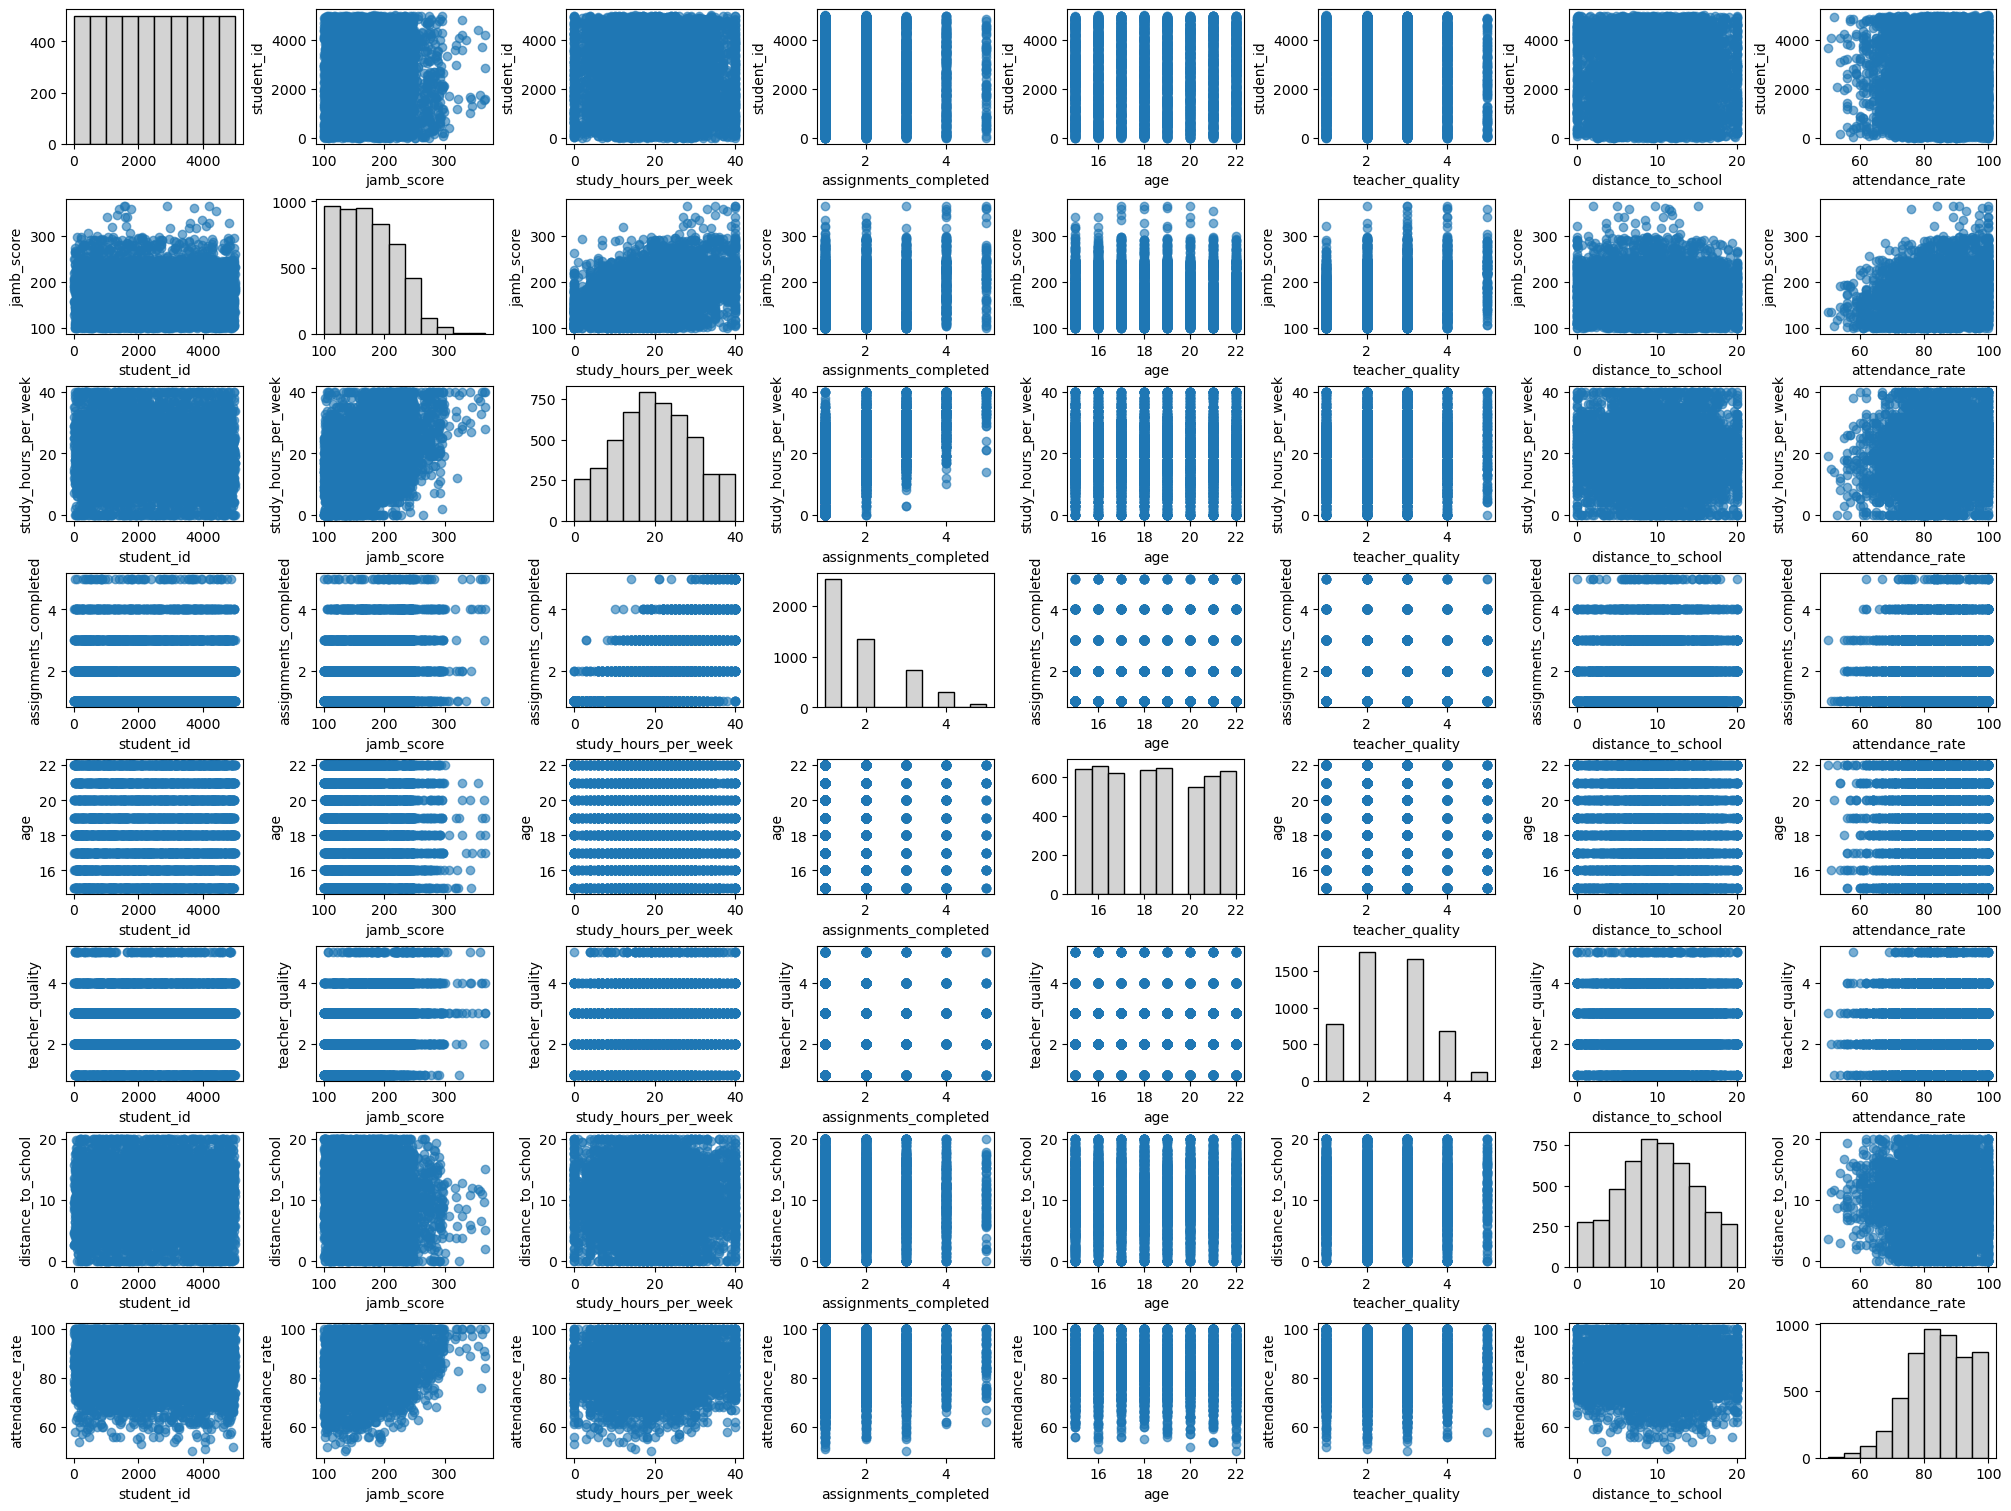

In [26]:
# Pair Plot of Numerical Columns

# Define the numerical columns to plot as a list of column names
numerical_columns = df.select_dtypes(include=[np.number]).columns
num_vars = len(numerical_columns)

fig, axs = plt.subplots(num_vars, num_vars, figsize=(20, 15), constrained_layout=True)

for i in range(num_vars):
    for j in range(num_vars):
        if i == j:
            axs[i, j].hist(df[numerical_columns[i]], bins=10, color='lightgray', edgecolor='black')
        else:
            axs[i, j].scatter(df[numerical_columns[j]], df[numerical_columns[i]], alpha=0.6)
            axs[i, j].set_xlabel(numerical_columns[j])
            axs[i, j].set_ylabel(numerical_columns[i])
plt.show()

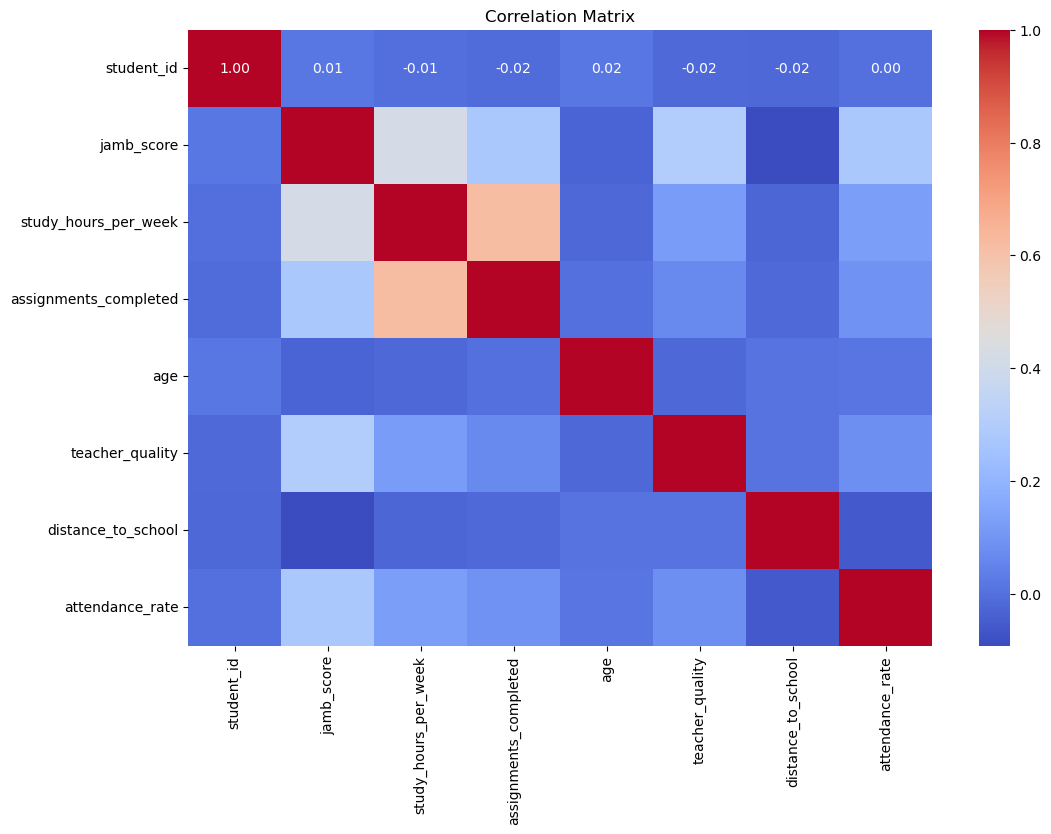

In [27]:
# Correlation heatmap

num_variable= df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(num_variable.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

C:\Users\Samuel C. Agbai\AppData\Local\Temp\ipykernel_16016\2799305693.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_scores_by_study_hours = df.groupby('study_hours_category')['jamb_score'].sum().reset_index()
C:\Users\Samuel C. Agbai\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


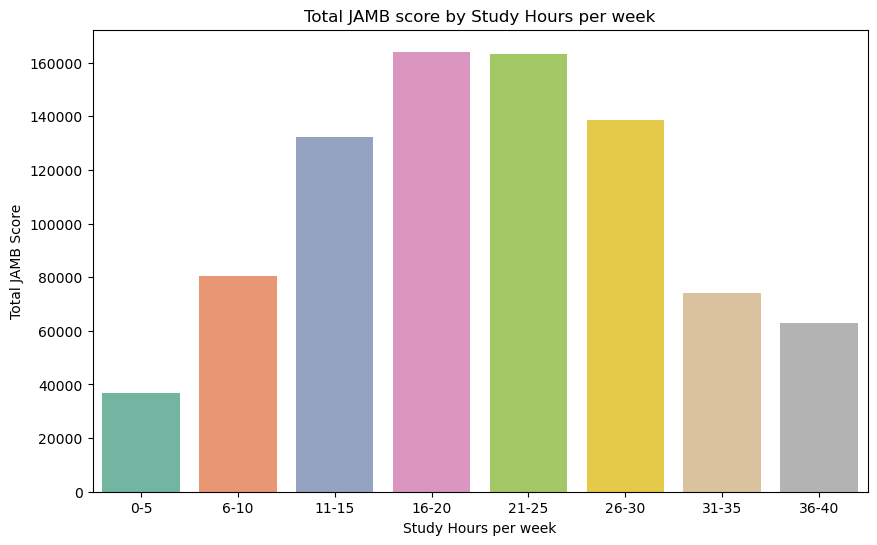

In [28]:
# Total JAMB Score by Study Hours per week
# Creating categories for Study hours
df['study_hours_category']=pd.cut(df['study_hours_per_week'], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40],
                                  labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40'])

# Calculating the total JAMB score for each study hours category
avg_scores_by_study_hours = df.groupby('study_hours_category')['jamb_score'].sum().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_scores_by_study_hours, x='study_hours_category', y='jamb_score', palette='Set2')
plt.title("Total JAMB score by Study Hours per week")
plt.xlabel("Study Hours per week")
plt.ylabel("Total JAMB Score")
plt.show()

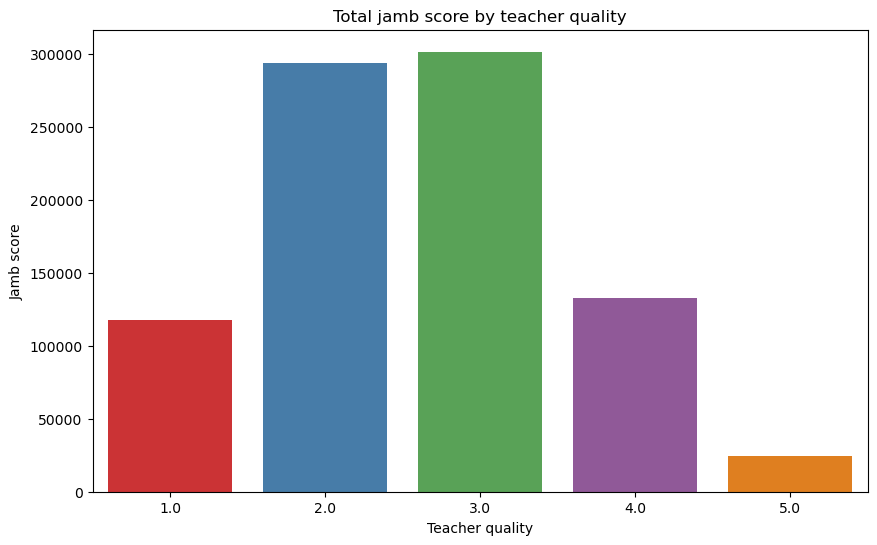

In [29]:
# Total jamb score by teacher quality
# calculating the total jamb score for teacher quality rating
avg_scores_by_teacher_quality = df.groupby('teacher_quality')['jamb_score'].sum().reset_index()

# plotting
plt.figure(figsize=(10, 6))
sns.barplot(data = avg_scores_by_teacher_quality, x='teacher_quality', y= 'jamb_score', palette = 'Set1')
plt.title("Total jamb score by teacher quality")
plt.xlabel("Teacher quality")
plt.ylabel("Jamb score")
plt.show()

#### 2. INVESTIGATE THE IMPACT OF SOCIOECONOMIC STATUS AND PARENTAL EDUCATION ON JAMB SCORE

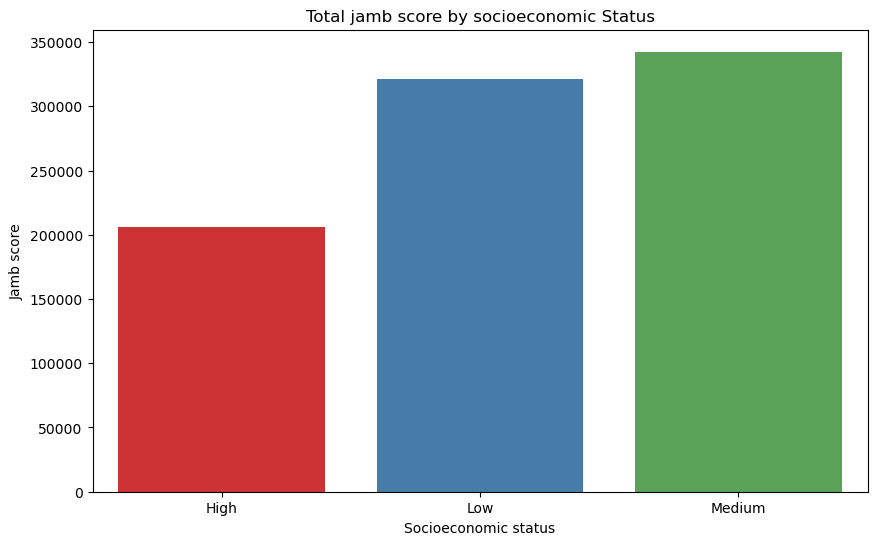

In [30]:
# Calculate the mean JAMB score for each socioeconomic status
avg_scores = df.groupby('socioeconomic_status')['jamb_score'].sum().reset_index()

# plotting our bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data = avg_scores, x='socioeconomic_status', y= 'jamb_score', palette = 'Set1')
plt.title("Total jamb score by socioeconomic Status")
plt.xlabel("Socioeconomic status")
plt.ylabel("Jamb score")
plt.show()

In [31]:
df.head()

,student_id,jamb_score,study_hours_per_week,assignments_completed,age,gender,socioeconomic_status,parent_education_level,teacher_quality,distance_to_school,school_type,school_location,parent_involvement,it_knowledge,attendance_rate,extra_tutorials,access_to_learning_materials,study_hours_category
0,1,192,22.0,2,17,Male,Low,Tertiary,4.0,12.4,Public,Urban,High,Medium,78.0,Yes,Yes,21-25
1,2,207,14.0,1,15,Male,High,Secondary,4.0,2.7,Public,Rural,High,High,88.0,No,Yes,11-15
2,3,182,29.0,2,20,Female,High,Tertiary,2.0,9.6,Public,Rural,High,Medium,87.0,Yes,Yes,26-30
3,4,210,29.0,1,22,Female,Medium,Tertiary,2.0,2.6,Public,Urban,Medium,High,99.0,No,Yes,26-30
4,5,199,12.0,1,22,Female,Medium,Tertiary,3.0,8.8,Public,Urban,Medium,Medium,98.0,No,Yes,11-15


In [32]:
df['parent_education_level'].value_counts()

parent_education_level
Secondary    1905
Primary      1618
Tertiary     1477
Name: count, dtype: int64

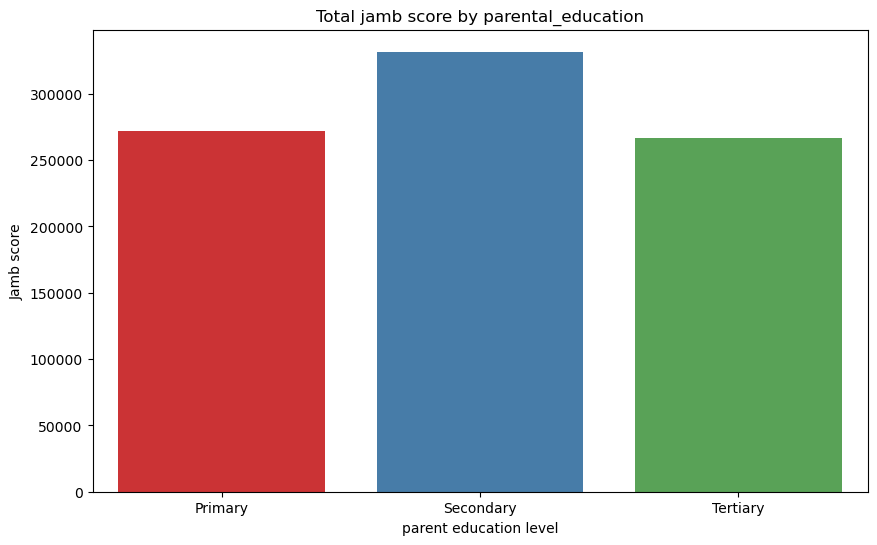

In [33]:
# Total jamb score by parental education
# calculating the total jamb score by parental education
avg_scores_by_parent_education_level = df.groupby('parent_education_level')['jamb_score'].sum().reset_index()

# plotting
plt.figure(figsize=(10, 6))
sns.barplot(data = avg_scores_by_parent_education_level, x='parent_education_level', y= 'jamb_score', palette = 'Set1')
plt.title("Total jamb score by parental_education")
plt.xlabel("parent education level")
plt.ylabel("Jamb score")
plt.show()

#### 3. ANALYZE THE COMPARISON OF PERFORMANCE BETWEEN PUBLIC AND PRIVATE SCHOOLS

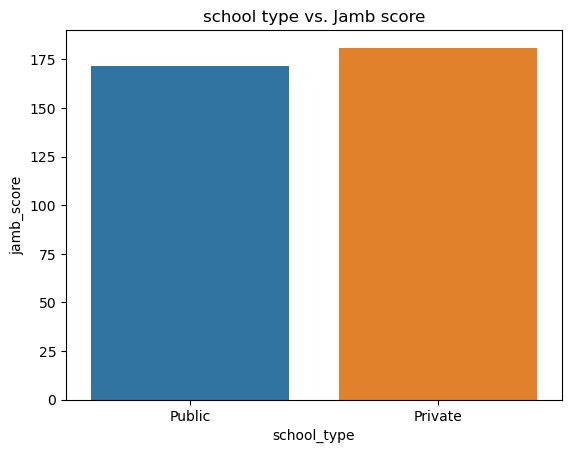

In [34]:
# school_type vs Jamb_score bar plot
sns.barplot(data = df, x= 'school_type', y = 'jamb_score', errorbar = None)
plt.title("school type vs. Jamb score")
plt.show()

In [35]:
df.jamb_score.value_counts()

jamb_score
118    50
148    49
117    47
116    47
157    47
       ..
346     1
320     1
269     1
279     1
355     1
Name: count, Length: 220, dtype: int64

In [36]:
df.jamb_score.mean()

174.0746

In [37]:
df.jamb_score.sum()

870373

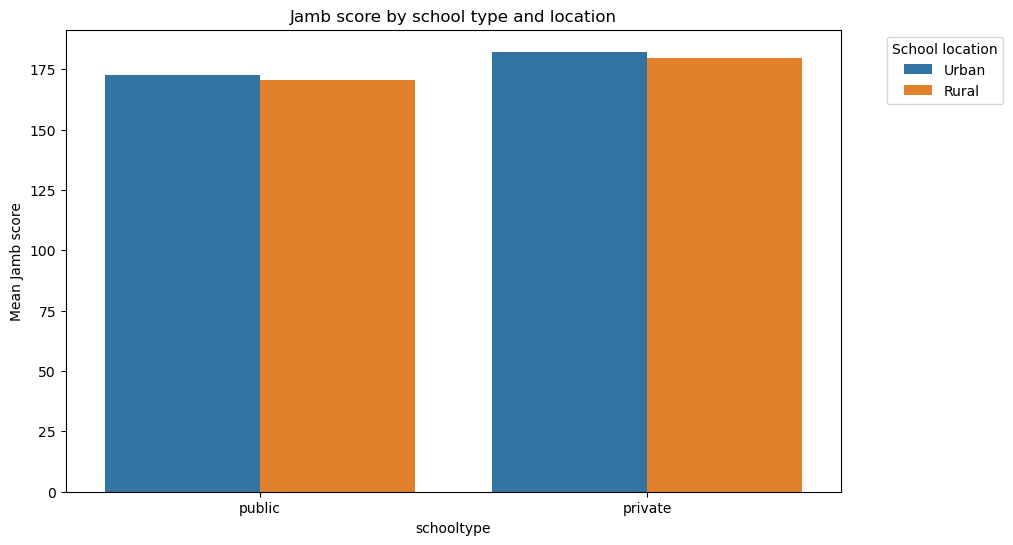

In [38]:
# Bar plot of total scores by school type and location
plt.figure(figsize=(10, 6))
sns.barplot(x='school_type', y= 'jamb_score', hue= 'school_location', data= df, errorbar = None)
plt.xticks([0,1], ['public', 'private'])
plt.title("Jamb score by school type and location")
plt.xlabel("schooltype")
plt.ylabel("Mean Jamb score")
plt.legend(title = 'School location', bbox_to_anchor = (1.05, 1), loc= 'upper left')
plt.show()

4. Analyze the Effect of IT Knowledge on JAMB Performance:

In [39]:
df.columns

Index(['student_id', 'jamb_score', 'study_hours_per_week',
       'assignments_completed', 'age', 'gender', 'socioeconomic_status',
       'parent_education_level', 'teacher_quality', 'distance_to_school',
       'school_type', 'school_location', 'parent_involvement', 'it_knowledge',
       'attendance_rate', 'extra_tutorials', 'access_to_learning_materials',
       'study_hours_category'],
      dtype='object')

In [40]:
df['it_knowledge'].value_counts()

it_knowledge
Medium    1970
Low       1843
High      1187
Name: count, dtype: int64

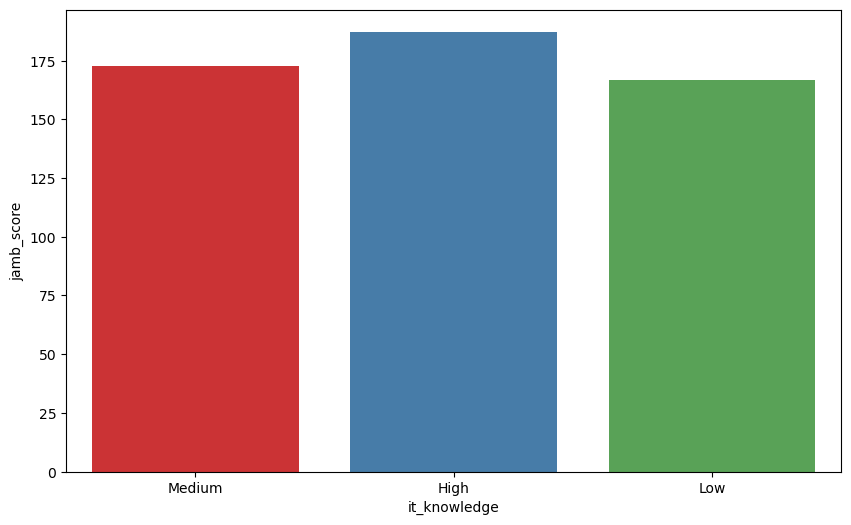

In [43]:
score_by_it_knowledge = df.groupby('it_knowledge')['jamb_score'].sum().reset_index()

plt.figure(figsize = (10,6))
sns.barplot( data = df, x = 'it_knowledge', y = 'jamb_score', palette = 'Set1', errorbar= None)
plt.title = ('Effect of IT knowledge on Jamb score')
plt.xlabel = ('IT knowledge')
plt.ylabel = ('Jamb score')
plt.show()


In [42]:
score_by_it_knowledge = df.groupby('it_knowledge')['jamb_score'].sum().reset_index()
plt.figure(figsize = (10,6))
sns.barplot( data = 'score_by_it_knowledge', x = 'it_knowledge', y = 'jamb_score', errorbar= None)
plt.title = ('z')
plt.xlabel = ('x')
plt.ylabel = ('y')
plt.show()

AttributeError: 'str' object has no attribute 'get'

<Figure size 1000x600 with 0 Axes>

5. Check the Influence of Extra Tutorials on Student Success:

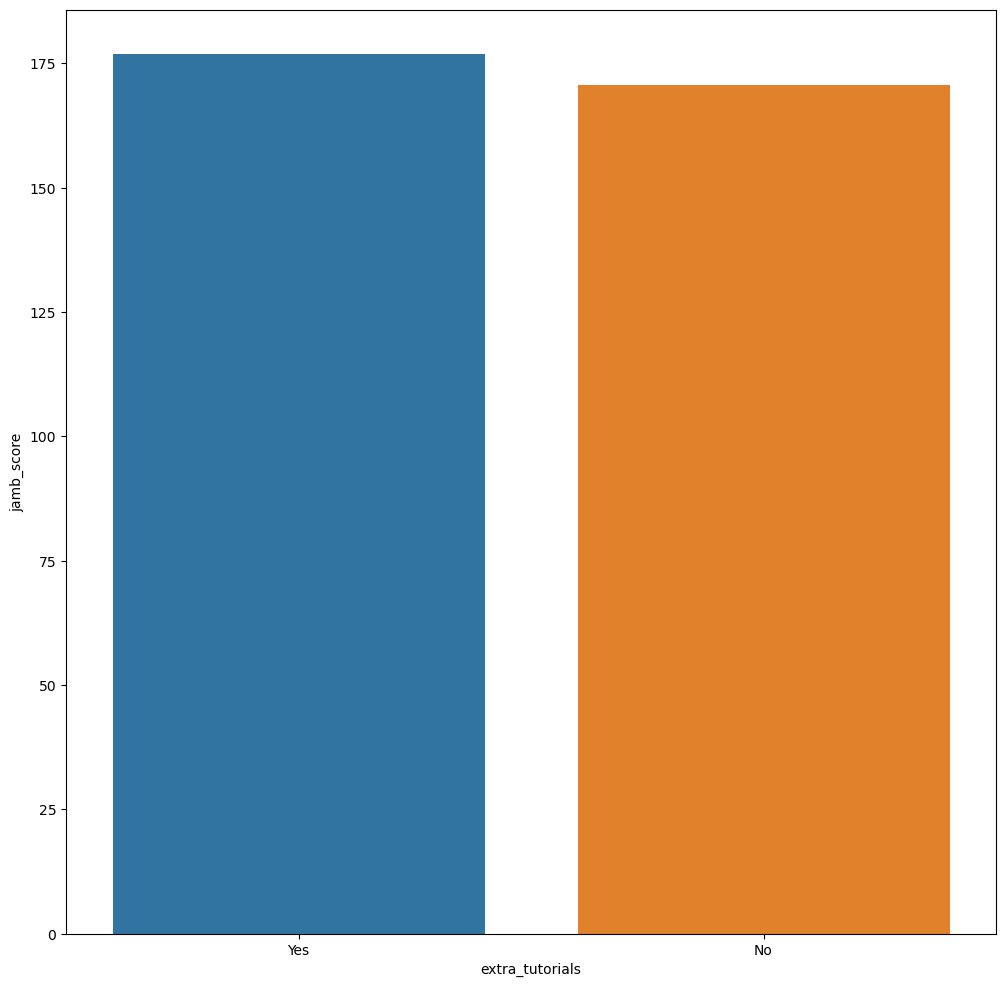

In [44]:
plt.figure(figsize = (12,12))
sns.barplot(data = df, x= 'extra_tutorials', y= 'jamb_score', errorbar= None)
plt.tiltle = ('Influence of Extra Tutorials on Student Success')
plt.xlabel = ('extra_tutorials')
plt.ylabel = ('jamb_score')
plt.show()

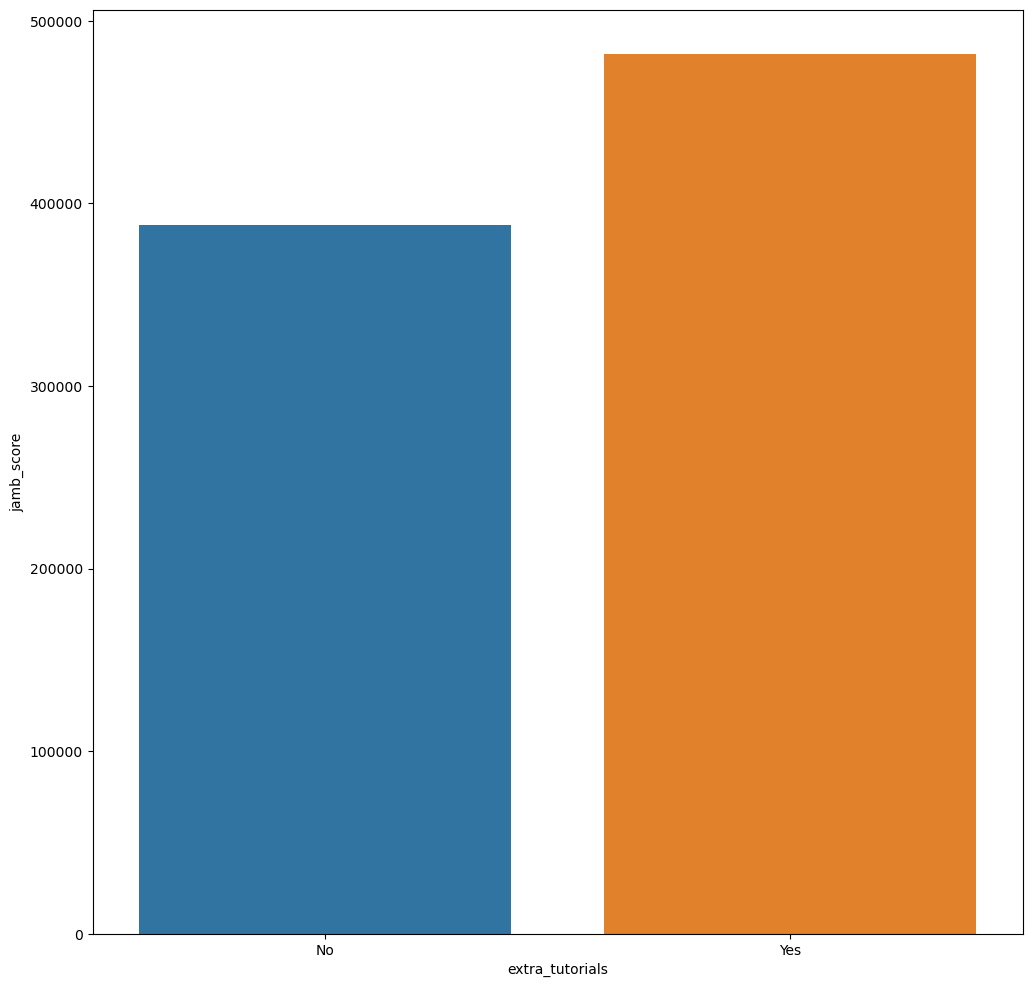

In [45]:
scores_by_extra_tutorials = df.groupby('extra_tutorials')['jamb_score'].sum().reset_index()
plt.figure(figsize = (12,12))
sns.barplot(data = scores_by_extra_tutorials, x= 'extra_tutorials', y= 'jamb_score', errorbar= None)
plt.tiltle = ('Influence of Extra Tutorials on Student Success')
plt.xlabel = ('extra_tutorials')
plt.ylabel = ('jamb_score')
plt.show()